# PS1 Data
Authors
- David W Hogg (NYU)
- Clark Miyamoto (NYU)

Requirements:
- `astropy`

# Get the Labels

In [1]:
import numpy as np
from astropy.io import fits # You might need to pip install this
import matplotlib.pyplot as plt # only needed for verification

In [2]:
path_labels = "./labels.fits"
allstar = fits.open(path_labels)

(5.0, 0.0)

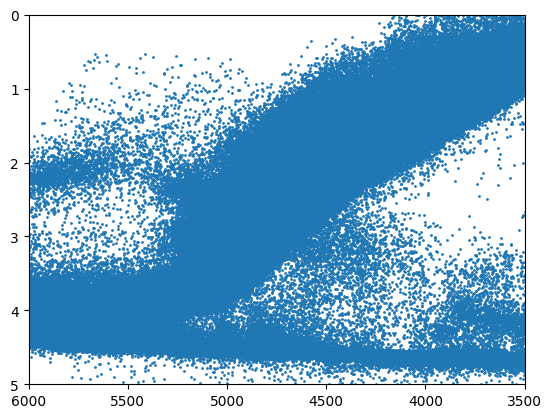

In [3]:
# the labels are in an enormous table in element [1] of this FITS file
labels = allstar[1].data
plt.scatter(labels['TEFF'], labels['LOGG'], s=1)
plt.xlim(6000, 3500)
plt.ylim(5, 0)

In [4]:
# make a reasonable red-giant-branch sample
RGB = True
RGB = np.logical_and(RGB, labels['TEFF'] > 3500.)
RGB = np.logical_and(RGB, labels['TEFF'] < 5400.)
RGB = np.logical_and(RGB, labels['LOGG'] < 3.0)
RGB = np.logical_and(RGB, labels['LOGG'] > 0.0)
RGB = np.logical_and(RGB, labels['H'] < 10.5)
print(np.sum(RGB))

145991


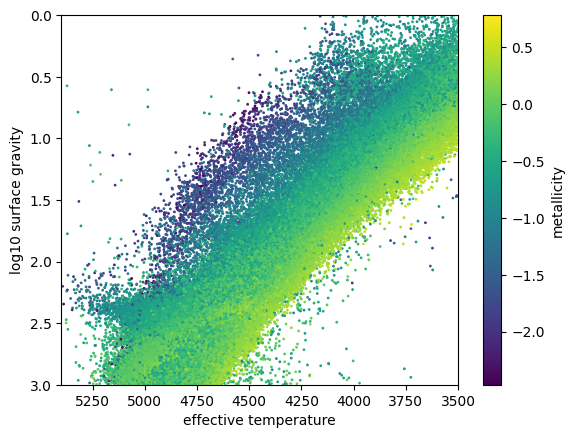

In [5]:
# make a plot that an astronomer likes to see
RGB_labels = labels[RGB]
plt.scatter(RGB_labels['TEFF'], RGB_labels['LOGG'], c=RGB_labels['FE_H'], s=1)
plt.xlim(5400, 3500)
plt.xlabel("effective temperature")
plt.ylim(3., 0.)
plt.ylabel("log10 surface gravity")
plt.colorbar(label="metallicity")

In [6]:
# make train, validation, and test data sets
rng = np.random.default_rng(17)
N_RGB = len(RGB_labels)
N_train, N_valid, N_test = 1024, 256, 512
I = rng.permutation(N_RGB)
I_train = I[0:N_train]
I_valid = I[N_train:N_train+N_valid]
I_test = I[N_train+N_valid:N_train+N_valid+N_test]

train_labels = RGB_labels[I_train]
valid_labels = RGB_labels[I_valid]
test_labels = RGB_labels[I_test]
print(len(train_labels), len(valid_labels), len(test_labels))

1024 256 512


Here how you get `LOGG`

In [7]:
train_labels_logg = train_labels['LOGG']
print(train_labels_logg.shape) # (num_spectra, 1)


(1024,)


# Get the Features

In [8]:
import numpy as np
from matplotlib import pyplot as plt

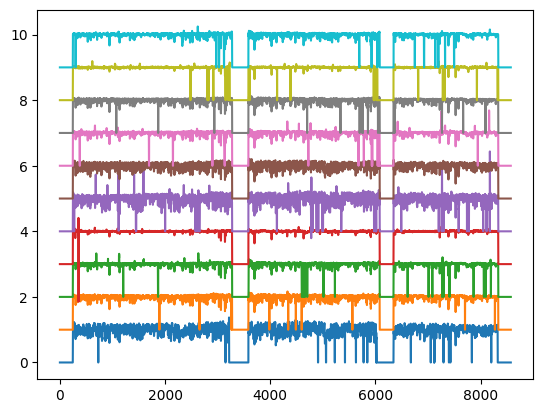

In [9]:
train_features = np.load('./train_features.npy')
valid_features = np.load('./valid_features.npy')
test_features = np.load('./test_features.npy')
for i in range(10):
    plt.plot(train_features[i] + i)

In [10]:
print(train_features.shape) # (num_spectra, num_pixels)

(1024, 8575)


____

# If you want to download more data

Run the `Get Labels` section, and then run this!

Adjust `N_train`, `N_valid`, and `N_test`.

In [11]:
# make train, validation, and test data sets
# rng = np.random.default_rng(17)
# N_RGB = len(RGB_labels)
# N_train, N_valid, N_test = 8192, 2048, 4096 #= 1024, 256, 512 # <- Adjust these for more data! 
# I = rng.permutation(N_RGB)
# I_train = I[0:N_train]
# I_valid = I[N_train:N_train+N_valid]
# I_test = I[N_train+N_valid:N_train+N_valid+N_test]
# train_labels = RGB_labels[I_train]
# valid_labels = RGB_labels[I_valid]
# test_labels = RGB_labels[I_test]
# print(len(train_labels), len(valid_labels), len(test_labels))

In [12]:
# base_url = "https://data.sdss.org/sas/dr17/apogee/spectro/aspcap/dr17/synspec_rev1/"
# def get_features(labels):
#     features = None
#     for l in labels:
#         url = base_url + l['TELESCOPE'] + "/" + l['FIELD'] + "/aspcapStar-dr17-" + l['APOGEE_ID'] + ".fits"
#         x = fits.open(url)[1].data
#         if features is None:
#             features = x[None, :]
#         else:
#             features = np.concatenate((features, x[None, :]), axis=0)
#     return features

In [13]:
# # Downloads data from SDSS
# # This will take a while, the first time you run it. Don't be alarmed.
# train_features_downloaded = get_features(train_labels)
# valid_features_downloaded = get_features(valid_labels)
# test_features_downloaded = get_features(test_labels)
# print(train_features_downloaded.shape, valid_features_downloaded.shape, test_features_downloaded.shape)

This is where my results start

In [14]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

TARGET_LABEL = 'LOGG' 

X_train = torch.from_numpy(train_features.astype(np.float32))
X_valid = torch.from_numpy(valid_features.astype(np.float32))
X_test  = torch.from_numpy(test_features.astype(np.float32))
y_train = torch.from_numpy(train_labels[TARGET_LABEL].astype(np.float32).reshape(-1, 1))
y_valid = torch.from_numpy(valid_labels[TARGET_LABEL].astype(np.float32).reshape(-1, 1))
y_test  = torch.from_numpy(test_labels[TARGET_LABEL].astype(np.float32).reshape(-1, 1))


In [15]:
## linear regression

#hyper parameters
LEARNING_RATE = 1e-3
EPOCHS        = 100
BATCH_SIZE    = 32
WEIGHT_DECAY  = 0.0
OPTIMIZER     = 'adam'
CRITERION     = nn.MSELoss()  #  | nn.L1Loss() | nn.HuberLoss(delta=1.0)

Epoch 20/100 | Train: 0.0917 | Valid: 0.1002
Epoch 40/100 | Train: 0.1486 | Valid: 0.1137
Epoch 60/100 | Train: 0.0963 | Valid: 0.1158
Epoch 80/100 | Train: 0.0588 | Valid: 0.1526
Epoch 100/100 | Train: 0.0500 | Valid: 0.0859


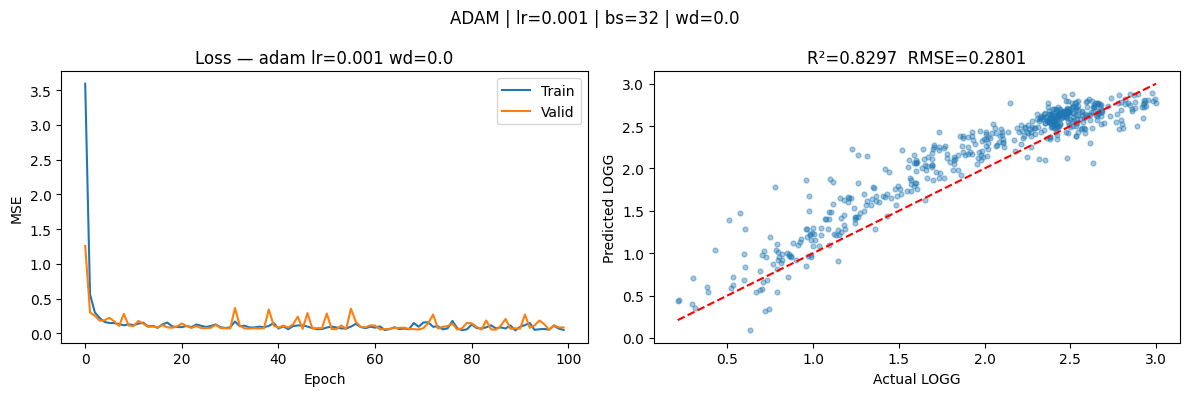

Test MSE: 0.0785 | RMSE: 0.2801 | R²: 0.8297


In [17]:
loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
model  = nn.Linear(X_train.shape[1], 1)
optim  = {'adam': torch.optim.Adam, 'sgd': torch.optim.SGD, 'rmsprop': torch.optim.RMSprop}
optimizer = optim[OPTIMIZER](model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_losses, valid_losses = [], []
for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = CRITERION(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))
    model.eval()
    with torch.no_grad():
        valid_losses.append(CRITERION(model(X_valid), y_valid).item())
    if epoch % max(1, EPOCHS // 5) == 0:
        print(f'Epoch {epoch}/{EPOCHS} | Train: {train_losses[-1]:.4f} | Valid: {valid_losses[-1]:.4f}')

# ── Evaluate on test set ──
model.eval()
with torch.no_grad():
    y_pred   = model(X_test)
    test_mse = CRITERION(y_pred, y_test).item()
    r2       = (1 - ((y_test - y_pred)**2).sum() / ((y_test - y_test.mean())**2).sum()).item()

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(valid_losses, label='Valid')
ax1.set_title(f'Loss — {OPTIMIZER} lr={LEARNING_RATE} wd={WEIGHT_DECAY}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.legend()
ax2.scatter(y_test.numpy(), y_pred.numpy(), alpha=0.4, s=12)
lims = [y_test.min(), y_test.max()]
ax2.plot(lims, lims, 'r--')
ax2.set_xlabel(f'Actual {TARGET_LABEL}'); ax2.set_ylabel(f'Predicted {TARGET_LABEL}')
ax2.set_title(f'R²={r2:.4f}  RMSE={test_mse**0.5:.4f}')
plt.suptitle(f'{OPTIMIZER.upper()} | lr={LEARNING_RATE} | bs={BATCH_SIZE} | wd={WEIGHT_DECAY}')
plt.tight_layout(); plt.show()
print(f'Test MSE: {test_mse:.4f} | RMSE: {test_mse**0.5:.4f} | R²: {r2:.4f}')

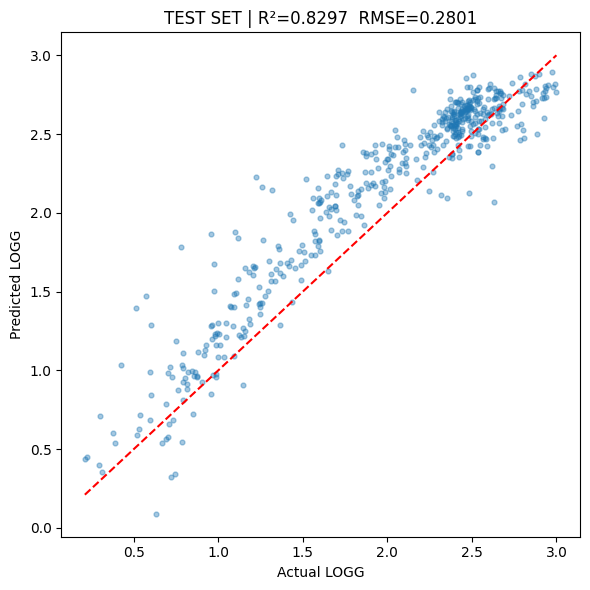

Test MSE: 0.0785 | RMSE: 0.2801 | R²: 0.8297


In [18]:

# Test eval 
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    test_mse    = nn.MSELoss()(y_pred_test, y_test).item()
    r2_test     = (1 - ((y_test - y_pred_test)**2).sum() / ((y_test - y_test.mean())**2).sum()).item()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.numpy(), y_pred_test.numpy(), alpha=0.4, s=12)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--')
ax.set_xlabel(f'Actual {TARGET_LABEL}'); ax.set_ylabel(f'Predicted {TARGET_LABEL}')
ax.set_title(f'TEST SET | R²={r2_test:.4f}  RMSE={test_mse**0.5:.4f}')
plt.tight_layout(); plt.show()
print(f'Test MSE: {test_mse:.4f} | RMSE: {test_mse**0.5:.4f} | R²: {r2_test:.4f}')

My data converges which is good, but my R^2 isnt the best. i dont know what would be a good R^2. this looks fine to me tbh.

In [19]:
# K nearest neighbors

X_train_np = train_features
X_valid_np = valid_features
X_test_np  = test_features
y_train_np = train_labels[TARGET_LABEL].astype(np.float32)
y_valid_np = valid_labels[TARGET_LABEL].astype(np.float32)
y_test_np  = test_labels[TARGET_LABEL].astype(np.float32)

In [20]:

def knn_predict(X_train, y_train, X_query, k, metric='euclidean', weights='uniform'):
    """
    X_train : (n_train, n_features)
    X_query : (n_query, n_features)
    y_train : (n_train,)
    """
    # ── Compute pairwise distances ──
    if metric == 'euclidean':
        # Efficient euclidean distance using matrix expansion
        # ||a - b||² = ||a||² + ||b||² - 2a·bᵀ
        train_sq = (X_train ** 2).sum(axis=1, keepdims=True)   # (n_train, 1)
        query_sq = (X_query ** 2).sum(axis=1, keepdims=True)   # (n_query, 1)
        dists    = np.sqrt(train_sq.T + query_sq - 2 * X_query @ X_train.T)  # (n_query, n_train)
    elif metric == 'manhattan':
        # Loop is slower but manhattan doesn't have the same matrix trick
        dists = np.array([[np.abs(X_query[i] - X_train).sum(axis=1)]
                          for i in range(len(X_query))]).squeeze()
    
    # ── Find k nearest neighbours ──
    k_indices = np.argsort(dists, axis=1)[:, :k]   # (n_query, k)
    k_dists   = np.take_along_axis(dists, k_indices, axis=1)
    k_labels  = y_train[k_indices]                  # (n_query, k)
    
    # ── Aggregate ──
    if weights == 'uniform':
        predictions = k_labels.mean(axis=1)
    elif weights == 'distance':
        # Closer neighbours get higher weight (1/distance)
        # Add small epsilon to avoid division by zero for exact matches
        w            = 1.0 / (k_dists + 1e-10)
        predictions  = (w * k_labels).sum(axis=1) / w.sum(axis=1)
    
    return predictions

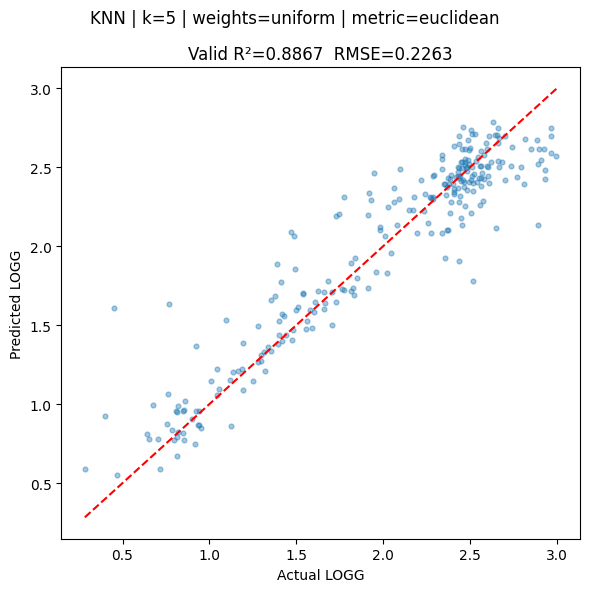

Valid MSE: 0.0512 | RMSE: 0.2263 | R²: 0.8867


In [23]:


# KNN — k=5, uniform weights

K       = 5
WEIGHTS = 'uniform'    # 'uniform' | 'distance'
METRIC  = 'euclidean'  # 'euclidean' | 'manhattan'
# ══════════════════════════════════════════

y_pred_valid = knn_predict(X_train_np, y_train_np, X_valid_np, k=K, metric=METRIC, weights=WEIGHTS)

valid_mse = np.mean((y_valid_np - y_pred_valid) ** 2)
ss_res    = ((y_valid_np - y_pred_valid) ** 2).sum()
ss_tot    = ((y_valid_np - y_valid_np.mean()) ** 2).sum()
valid_r2  = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_valid_np, y_pred_valid, alpha=0.4, s=12)
lims = [y_valid_np.min(), y_valid_np.max()]
ax.plot(lims, lims, 'r--')
ax.set_xlabel(f'Actual {TARGET_LABEL}'); ax.set_ylabel(f'Predicted {TARGET_LABEL}')
ax.set_title(f'Valid R²={valid_r2:.4f}  RMSE={valid_mse**0.5:.4f}')
plt.suptitle(f'KNN | k={K} | weights={WEIGHTS} | metric={METRIC}')
plt.tight_layout(); plt.show()
print(f'Valid MSE: {valid_mse:.4f} | RMSE: {valid_mse**0.5:.4f} | R²: {valid_r2:.4f}')

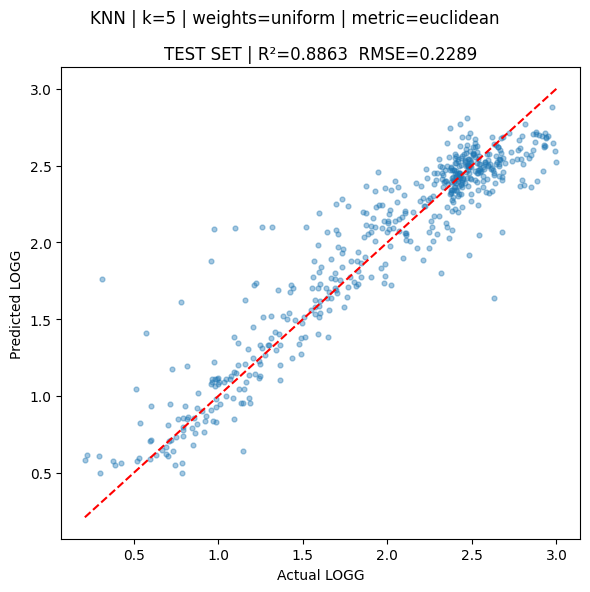

Test MSE: 0.0524 | RMSE: 0.2289 | R²: 0.8863


In [22]:

# FINAL KNN TEST EVALUATION


y_pred_test = knn_predict(X_train_np, y_train_np, X_test_np, k=K, metric=METRIC, weights=WEIGHTS)

test_mse = np.mean((y_test_np - y_pred_test) ** 2)
ss_res   = ((y_test_np - y_pred_test) ** 2).sum()
ss_tot   = ((y_test_np - y_test_np.mean()) ** 2).sum()
test_r2  = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_np, y_pred_test, alpha=0.4, s=12)
lims = [y_test_np.min(), y_test_np.max()]
ax.plot(lims, lims, 'r--')
ax.set_xlabel(f'Actual {TARGET_LABEL}'); ax.set_ylabel(f'Predicted {TARGET_LABEL}')
ax.set_title(f'TEST SET | R²={test_r2:.4f}  RMSE={test_mse**0.5:.4f}')
plt.suptitle(f'KNN | k={K} | weights={WEIGHTS} | metric={METRIC}')
plt.tight_layout(); plt.show()
print(f'Test MSE: {test_mse:.4f} | RMSE: {test_mse**0.5:.4f} | R²: {test_r2:.4f}')

This also looks good. but this data isnt that confusing and we have an actual model to compare.

In [24]:
#multi layer perceptron
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation):
        super().__init__()
        layers = []
        in_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(activation)
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, 1))  # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

Epoch 20/100 | Train: 0.0731 | Valid: 0.1029
Epoch 40/100 | Train: 0.0475 | Valid: 0.0545
Epoch 60/100 | Train: 0.0467 | Valid: 0.0595
Epoch 80/100 | Train: 0.0519 | Valid: 0.0505
Epoch 100/100 | Train: 0.0341 | Valid: 0.0560


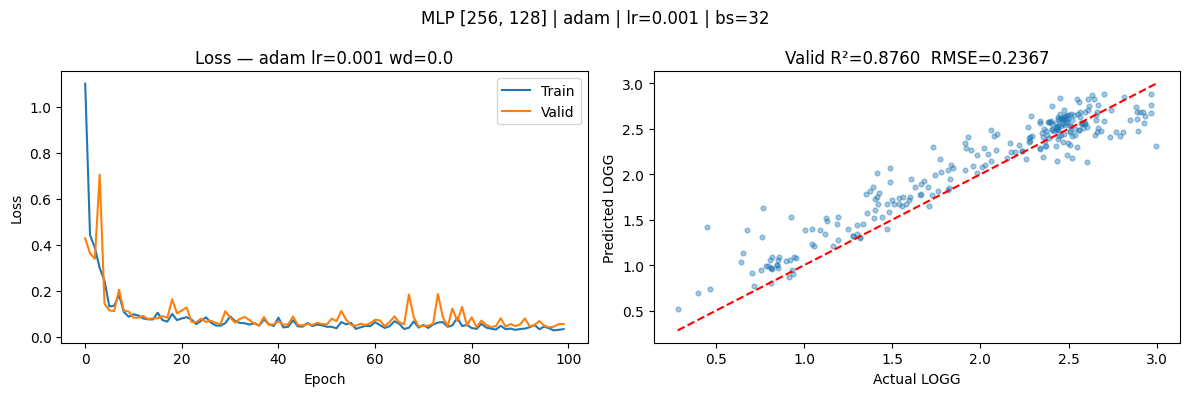

Valid MSE: 0.0560 | RMSE: 0.2367 | R²: 0.8760


In [ ]:

# MLP — 2 hidden layers

HIDDEN_LAYERS = [256, 128]       # one entry per hidden layer, value is number of neurons
ACTIVATION    = nn.ReLU()        # nn.ReLU() | nn.Tanh() | nn.Sigmoid() | nn.LeakyReLU()
LEARNING_RATE = 1e-3
EPOCHS        = 100
BATCH_SIZE    = 32
WEIGHT_DECAY  = 0.0
OPTIMIZER     = 'adam'           # 'adam' | 'sgd' | 'rmsprop'
CRITERION     = nn.MSELoss()     # nn.MSELoss() | nn.L1Loss() | nn.HuberLoss(delta=1.0)


loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
model  = MLP(input_dim=X_train.shape[1], hidden_layers=HIDDEN_LAYERS, activation=ACTIVATION)
optim  = {'adam': torch.optim.Adam, 'sgd': torch.optim.SGD, 'rmsprop': torch.optim.RMSprop}
optimizer = optim[OPTIMIZER](model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_losses, valid_losses = [], []
for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = CRITERION(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))
    model.eval()
    with torch.no_grad():
        valid_losses.append(CRITERION(model(X_valid), y_valid).item())
    if epoch % max(1, EPOCHS // 5) == 0:
        print(f'Epoch {epoch}/{EPOCHS} | Train: {train_losses[-1]:.4f} | Valid: {valid_losses[-1]:.4f}')

# ── Validation performance only ──
model.eval()
with torch.no_grad():
    y_pred_valid = model(X_valid)
    valid_mse    = CRITERION(y_pred_valid, y_valid).item()
    r2_valid     = (1 - ((y_valid - y_pred_valid)**2).sum() / ((y_valid - y_valid.mean())**2).sum()).item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(valid_losses, label='Valid')
ax1.set_title(f'Loss — {OPTIMIZER} lr={LEARNING_RATE} wd={WEIGHT_DECAY}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
ax2.scatter(y_valid.numpy(), y_pred_valid.numpy(), alpha=0.4, s=12)
lims = [y_valid.min(), y_valid.max()]
ax2.plot(lims, lims, 'r--')
ax2.set_xlabel(f'Actual {TARGET_LABEL}'); ax2.set_ylabel(f'Predicted {TARGET_LABEL}')
ax2.set_title(f'Valid R²={r2_valid:.4f}  RMSE={valid_mse**0.5:.4f}')
plt.suptitle(f'MLP {HIDDEN_LAYERS} | {OPTIMIZER} | lr={LEARNING_RATE} | bs={BATCH_SIZE}')
plt.tight_layout(); plt.show()
print(f'Valid MSE: {valid_mse:.4f} | RMSE: {valid_mse**0.5:.4f} | R²: {r2_valid:.4f}')

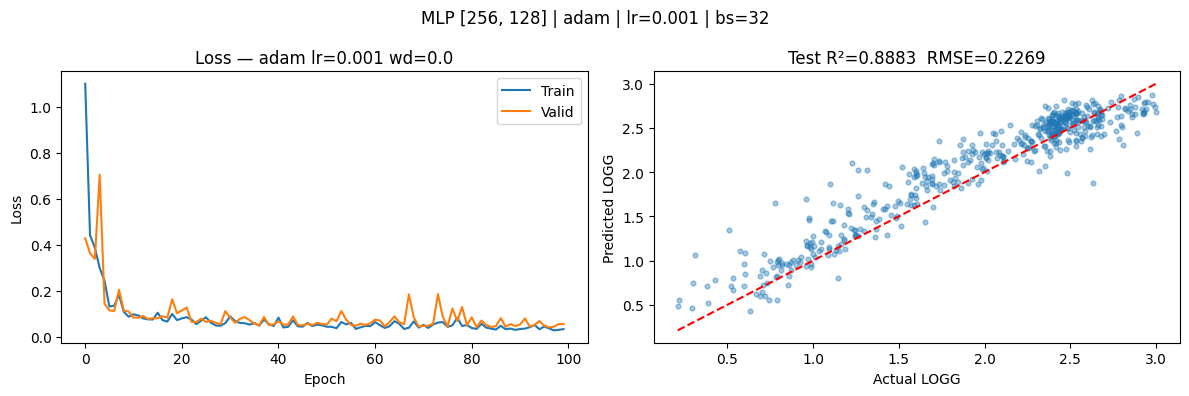

Test MSE: 0.0515 | RMSE: 0.2269 | R²: 0.8883


In [26]:
# ── Evaluate MLP on test set ──
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    test_mse    = CRITERION(y_pred_test, y_test).item()
    r2_test     = (1 - ((y_test - y_pred_test)**2).sum() / ((y_test - y_test.mean())**2).sum()).item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train'); ax1.plot(valid_losses, label='Valid')
ax1.set_title(f'Loss — {OPTIMIZER} lr={LEARNING_RATE} wd={WEIGHT_DECAY}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.scatter(y_test.numpy(), y_pred_test.numpy(), alpha=0.4, s=12)
lims = [y_test.min(), y_test.max()]
ax2.plot(lims, lims, 'r--')
ax2.set_xlabel(f'Actual {TARGET_LABEL}'); ax2.set_ylabel(f'Predicted {TARGET_LABEL}')
ax2.set_title(f'Test R²={r2_test:.4f}  RMSE={test_mse**0.5:.4f}')

plt.suptitle(f'MLP {HIDDEN_LAYERS} | {OPTIMIZER} | lr={LEARNING_RATE} | bs={BATCH_SIZE}')
plt.tight_layout(); plt.show()

print(f'Test MSE: {test_mse:.4f} | RMSE: {test_mse**0.5:.4f} | R²: {r2_test:.4f}')

This has minimized loss and the R^2 is fine. this is the same as what I expected for simple small models.